## Mental Health in the Workplace: Data Analysis Project

This project analyzes mental health survey data to understand patterns related to treatment-seeking behavior, workplace support, and demographic factors.

The goal is to identify factors that may influence whether individuals seek mental health treatment, with a focus on workplace mental health awareness and support.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [9]:
import pandas as pd

df = pd.read_csv("../data/survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## Initial Data Exploration

In this section, we explore the structure of the dataset, including the number of observations, available features, and missing values. This helps identify potential data quality issues before cleaning and analysis.

In [10]:
df.shape

(1259, 27)

In [11]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [13]:
df.isnull().sum().sort_values(ascending=False)

comments                     1095
state                         515
work_interfere                264
self_employed                  18
seek_help                       0
obs_consequence                 0
mental_vs_physical              0
phys_health_interview           0
mental_health_interview         0
supervisor                      0
coworkers                       0
phys_health_consequence         0
mental_health_consequence       0
leave                           0
anonymity                       0
Timestamp                       0
wellness_program                0
Age                             0
benefits                        0
tech_company                    0
remote_work                     0
no_employees                    0
treatment                       0
family_history                  0
Country                         0
Gender                          0
care_options                    0
dtype: int64

In [14]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## Data Cleaning

In this section, we clean and preprocess the dataset to handle missing values, standardize categories, and remove unrealistic data entries. This ensures the data is reliable for analysis.

In [15]:
df_clean = df.copy()

In [16]:
df_clean.columns = df_clean.columns.str.lower().str.strip().str.replace(" ", "_")
df_clean.head()

,timestamp,age,gender,country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [17]:
columns_to_drop = ["comments", "state", "timestamp"]

df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

In [18]:
df_clean = df_clean[(df_clean["age"] >= 18) & (df_clean["age"] <= 75)]

df_clean["age"].describe()

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: age, dtype: float64

In [19]:
df_clean["gender"] = df_clean["gender"].str.lower().str.strip()

female_terms = ["female", "f", "woman", "female ", "cis female"]
male_terms = ["male", "m", "man", "cis male", "male "]

df_clean["gender_clean"] = df_clean["gender"].apply(
    lambda x: "Female" if x in female_terms else ("Male" if x in male_terms else "Other/Unknown")
)

df_clean["gender_clean"].value_counts()

Male             974
Female           243
Other/Unknown     34
Name: gender_clean, dtype: int64

In [20]:
df_clean.isnull().sum().sort_values(ascending=False)

work_interfere               262
self_employed                 18
age                            0
anonymity                      0
obs_consequence                0
mental_vs_physical             0
phys_health_interview          0
mental_health_interview        0
supervisor                     0
coworkers                      0
phys_health_consequence        0
mental_health_consequence      0
leave                          0
wellness_program               0
seek_help                      0
gender                         0
care_options                   0
benefits                       0
tech_company                   0
remote_work                    0
no_employees                   0
treatment                      0
family_history                 0
country                        0
gender_clean                   0
dtype: int64

In [21]:
df_clean.to_csv("cleaned_mental_health.csv", index=False)

## Exploratory Data Analysis

In this section, we explore key patterns in the data using visualizations. The goal is to understand how factors such as gender, age, and workplace environment relate to mental health treatment.

In [42]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(visuals_path, exist_ok=True)

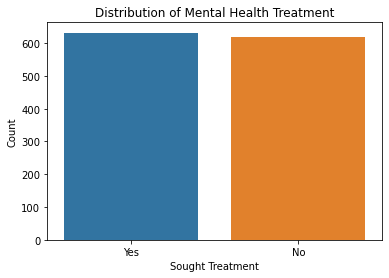

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x="treatment", data=df_clean)
plt.title("Distribution of Mental Health Treatment")
plt.xlabel("Sought Treatment")
plt.ylabel("Count")

plt.savefig(f"{visuals_path}/treatment_distribution.png", bbox_inches="tight")
plt.show()

### Insight:

The distribution shows how many individuals have sought treatment for mental health conditions. This provides a baseline understanding of treatment prevalence in the dataset.

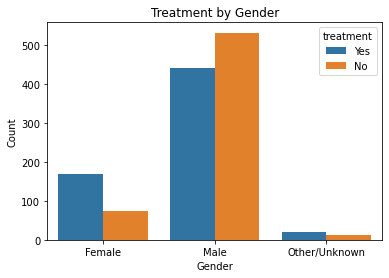

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender_clean", hue="treatment", data=df_clean)
plt.title("Treatment by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig(f"{visuals_path}/gender_treatment.png", bbox_inches="tight")
plt.show()

### Insight:

This visualization shows how treatment-seeking behavior differs across gender groups. It may highlight disparities in mental health awareness or access to care.

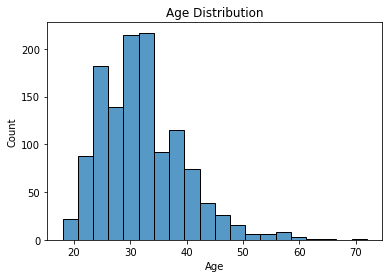

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig(f"{visuals_path}/age_distribution.png", bbox_inches="tight")
plt.show()

### Insight:

The age distribution helps us understand the demographic composition of the dataset and whether certain age groups are more represented.

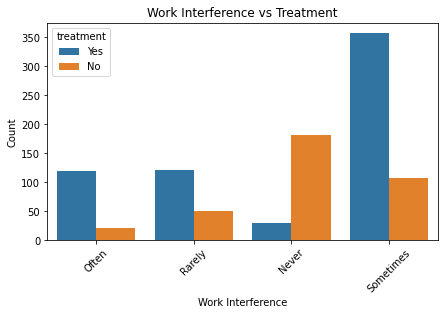

In [46]:
plt.figure(figsize=(7,4))
sns.countplot(x="work_interfere", hue="treatment", data=df_clean)
plt.title("Work Interference vs Treatment")
plt.xlabel("Work Interference")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.savefig(f"{visuals_path}/work_interfere_treatment.png", bbox_inches="tight")
plt.show()

### Insight:

This chart explores how mental health impacts workplace productivity and whether individuals experiencing work interference are more likely to seek treatment.

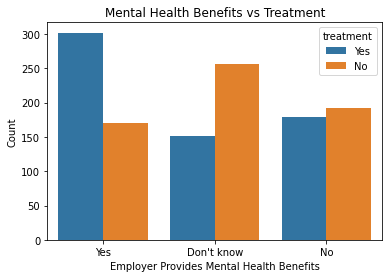

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(x="benefits", hue="treatment", data=df_clean)
plt.title("Mental Health Benefits vs Treatment")
plt.xlabel("Employer Provides Mental Health Benefits")
plt.ylabel("Count")

plt.savefig(f"{visuals_path}/benefits_treatment.png", bbox_inches="tight")
plt.show()

### Insight:

This visualization examines whether access to employer-provided mental health benefits is associated with treatment-seeking behavior.

## Conclusion

This analysis explored the relationship between demographic and workplace factors and mental health treatment-seeking behavior.

Key findings include:

- A significant portion of individuals reported seeking treatment for mental health conditions.
- Treatment patterns varied across gender groups, suggesting potential differences in awareness or access to care.
- Workplace factors, such as mental health benefits and work interference, appeared to influence whether individuals sought treatment.
- Employees experiencing higher levels of work interference were more likely to seek treatment, highlighting the impact of mental health on productivity.

Overall, the findings suggest that workplace support systems and open conversations around mental health may play a critical role in encouraging individuals to seek treatment.

Future analysis could involve predictive modeling to identify high-risk groups or deeper analysis of workplace policies and their effectiveness.